# Knightian Uncertainty Demonstration

Compare InfraBayesianAgent behavior with and without Knightian uncertainty (KU).

**Non-KU** (single belief): The infradistribution contains one a-measure. Lambda=1, b=0; the IB plumbing is a pass-through. Equivalent to standard Bayesian updating.

**KU** (multiple beliefs): The infradistribution contains multiple a-measures with different priors. At each step, the agent:
1. Takes the element-wise **min** over all measures' reward models (worst-case planning)
2. Updates each measure via **Definition 11** from *Basic Inframeasure Theory* — rescaling lambda and absorbing counterfactual surplus into offsets

This notebook demonstrates:
- How KU affects learning dynamics compared to non-KU
- Validation that single a-measure infrabayes agents behave identically to classical agents
- The role of `g` (counterfactual value) in the update rule

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

from ibrl.simulators import simulate
from ibrl.utils import construct_environment
from ibrl.environments import BernoulliBanditEnvironment
from ibrl.agents import InfraBayesianAgent, BernoulliBayesianAgent
from ibrl.infrabayesian.beliefs import BernoulliBelief, NewcombLikeBelief
from ibrl.infrabayesian.a_measure import AMeasure
from ibrl.infrabayesian.infradistribution import Infradistribution
from ibrl.outcome import Outcome

## Configuration

In [2]:
options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}
n = options["num_actions"]
shared = dict(num_actions=n, seed=options["seed"] + 0x01234567, epsilon=0.1)


def make_bernoulli(alpha, beta):
    """Create a BernoulliBelief with custom Beta prior."""
    b = BernoulliBelief(num_actions=n)
    b.alpha = np.array(alpha, dtype=float)
    b.beta = np.array(beta, dtype=float)
    return b


## 1. Non-KU vs KU across Bernoulli Bandit Environments

We test three agents across bernoulli bandits with different arm probabilities:

**Agents:**
- **Classic Bayesian**: BernoulliBayesianAgent — standard Bayesian learning baseline.
- **Non-KU**: InfraBayesianAgent with a single BernoulliBelief, uniform Beta(1,1) prior — should match Bayesian.
- **KU**: InfraBayesianAgent with two BernoulliBelief measures (pessimistic Beta(1,3) + optimistic Beta(3,1)).

**Environments:**
- **fair**: Both arms have p=0.5 (no best arm — tests exploration behavior)
- **optimistic**: Both arms have p=0.7 (high reward, no best arm)
- **pessimistic**: Both arms have p=0.3 (low reward, no best arm)

In [3]:
env_probs = {
    "p0=0.49 p1=0.51": [0.49, 0.51],
    "p0=0.3 p1=0.7": [0.3, 0.7],
    "p0=0.7 p1=0.8": [0.7, 0.8],
    "p0=0.2 p1=0.3": [0.2, 0.3],
}

def make_agents_bandit():
    return {
        "Bayesian": BernoulliBayesianAgent(**shared),
        "Infrabayesian w/ single a-measure": InfraBayesianAgent(
            **shared, beliefs=[make_bernoulli([1, 1], [1, 1])],
        ),
        "Infrabayesian w/ two a-measures (KU)": InfraBayesianAgent(
            **shared,
            beliefs=[
                make_bernoulli([1, 1], [3, 3]),  # pessimistic: Beta(1,3), mean=0.25
                make_bernoulli([3, 3], [1, 1]),  # optimistic:  Beta(3,1), mean=0.75
            ],
        ),
    }

results_bandit = {}
for env_label, probs in env_probs.items():
    results_bandit[env_label] = {}
    agents = make_agents_bandit()
    for agent_name, agent in agents.items():
        env = BernoulliBanditEnvironment(probs=probs, **options)
        print(f"Running: {env_label} / {agent_name}")
        results_bandit[env_label][agent_name] = simulate(env, agent, options)
        res = results_bandit[env_label][agent_name]
        print(f"  optimal: {res['optimal_reward']:.4f}  "
              f"final avg: {res['average_reward'][0, -50:].mean():.4f}")

Running: p0=0.49 p1=0.51 / Bayesian
  optimal: 0.5100  final avg: 0.5160
Running: p0=0.49 p1=0.51 / Infrabayesian w/ single a-measure
  optimal: 0.5100  final avg: 0.5160
Running: p0=0.49 p1=0.51 / Infrabayesian w/ two a-measures (KU)
  optimal: 0.5100  final avg: 0.5120
Running: p0=0.3 p1=0.7 / Bayesian
  optimal: 0.7000  final avg: 0.6960
Running: p0=0.3 p1=0.7 / Infrabayesian w/ single a-measure
  optimal: 0.7000  final avg: 0.6960
Running: p0=0.3 p1=0.7 / Infrabayesian w/ two a-measures (KU)
  optimal: 0.7000  final avg: 0.6960
Running: p0=0.7 p1=0.8 / Bayesian
  optimal: 0.8000  final avg: 0.8110
Running: p0=0.7 p1=0.8 / Infrabayesian w/ single a-measure
  optimal: 0.8000  final avg: 0.8110
Running: p0=0.7 p1=0.8 / Infrabayesian w/ two a-measures (KU)
  optimal: 0.8000  final avg: 0.8110
Running: p0=0.2 p1=0.3 / Bayesian
  optimal: 0.3000  final avg: 0.2980
Running: p0=0.2 p1=0.3 / Infrabayesian w/ single a-measure
  optimal: 0.3000  final avg: 0.2980
Running: p0=0.2 p1=0.3 / Infr

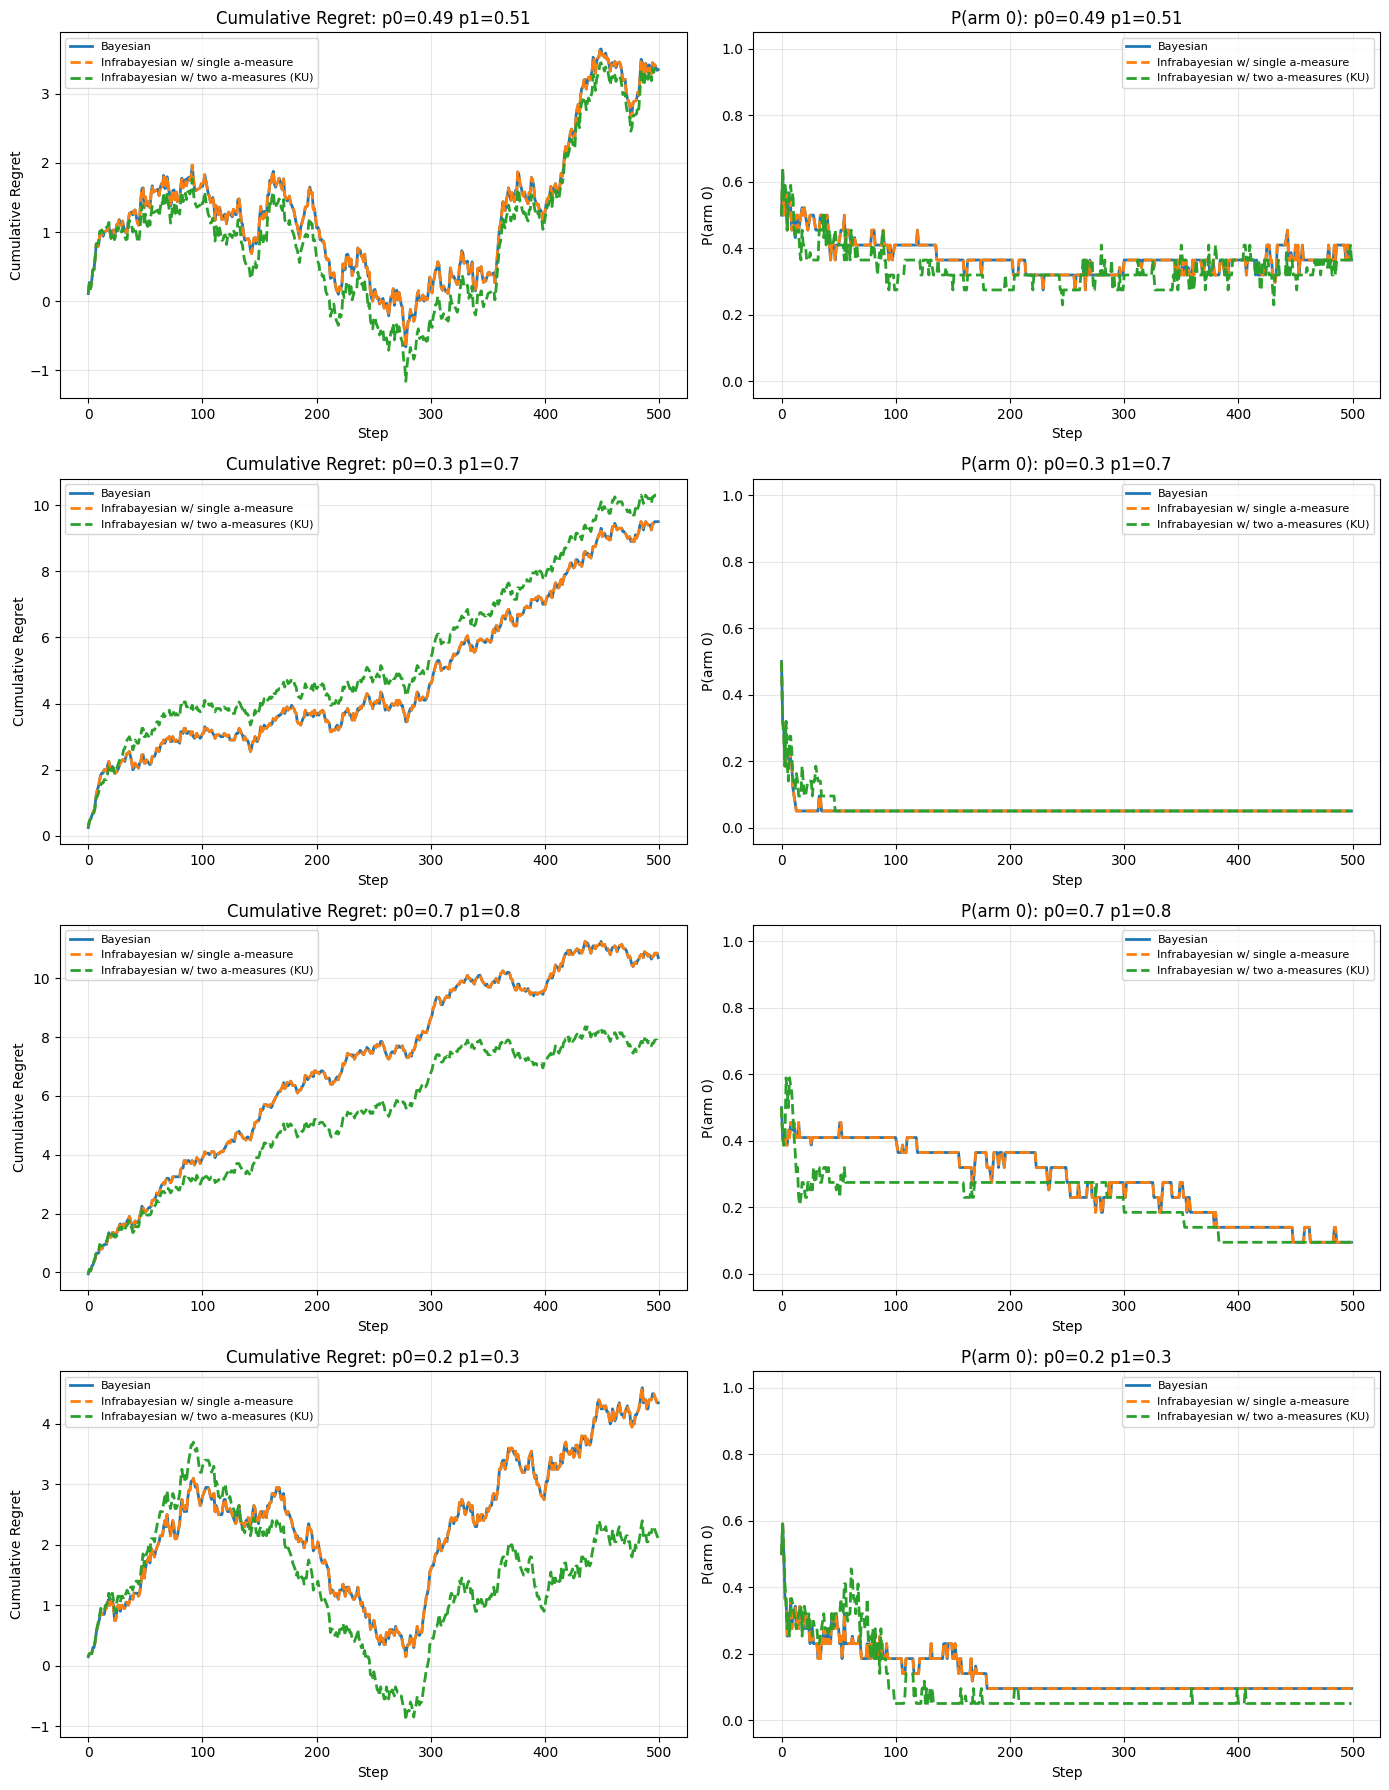

In [5]:
num_envs = len(env_probs)
fig, axes = plt.subplots(num_envs, 2, figsize=(14, 4.5 * num_envs))

for i, (env_label, agent_results) in enumerate(results_bandit.items()):
    # Cumulative regret
    ax = axes[i, 0]
    for agent_name, res in agent_results.items():
        avg = res["average_reward"][0, :]
        regret = np.cumsum(res["optimal_reward"] - avg)
        ls = "--" if "Infrabayesian" in agent_name else "-"
        ax.plot(regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(f"Cumulative Regret: {env_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Selection probabilities (arm 0)
    ax = axes[i, 1]
    for agent_name, res in agent_results.items():
        p0 = res["probabilities"][:, :, 0].mean(axis=0)
        ls = "--" if "Infrabayesian" in agent_name else "-"
        ax.plot(p0, label=f"{agent_name}", linewidth=2, ls=ls)
    ax.set_title(f"P(arm 0): {env_label}")
    ax.set_xlabel("Step")
    ax.set_ylabel("P(arm 0)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Effect of g (Counterfactual Value)

`g` controls how much value the agent assigns to the non-observed branch of the outcome space during KU updates.

- **g = 1.0** (default): Full value on counterfactual — preserves cohomogeneity (lambda + b = 1). Recommended by IB literature.
- **g = 0.5**: Partial counterfactual value — discounts unseen outcomes.
- **g = 0.0**: Zero counterfactual value — completely ignores what would have happened on the other branch. Degenerates to independent Bayesian updates per measure (no cross-measure interaction).

In [6]:
g_values = [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]
ku_beliefs = [
    make_bernoulli([1, 1], [3, 3]),
    make_bernoulli([3, 3], [1, 1]),
]

results_g = {}
for g in g_values:
    agent = InfraBayesianAgent(**shared, beliefs=ku_beliefs, g=g)
    env = construct_environment("bernoulli-bandit", options)
    label = f"KU, g={g}"
    print(f"Running: bernoulli-bandit / {label}")
    results_g[label] = simulate(env, agent, options)
    res = results_g[label]
    print(f"  optimal: {res['optimal_reward']:.4f}  "
          f"final avg: {res['average_reward'][0, -50:].mean():.4f}")

Running: bernoulli-bandit / KU, g=0.0
  optimal: 0.7278  final avg: 0.7070
Running: bernoulli-bandit / KU, g=0.3
  optimal: 0.7278  final avg: 0.7070
Running: bernoulli-bandit / KU, g=0.5
  optimal: 0.7278  final avg: 0.7070
Running: bernoulli-bandit / KU, g=0.7
  optimal: 0.7278  final avg: 0.7090
Running: bernoulli-bandit / KU, g=0.9
  optimal: 0.7278  final avg: 0.7120
Running: bernoulli-bandit / KU, g=1.0
  optimal: 0.7278  final avg: 0.7120


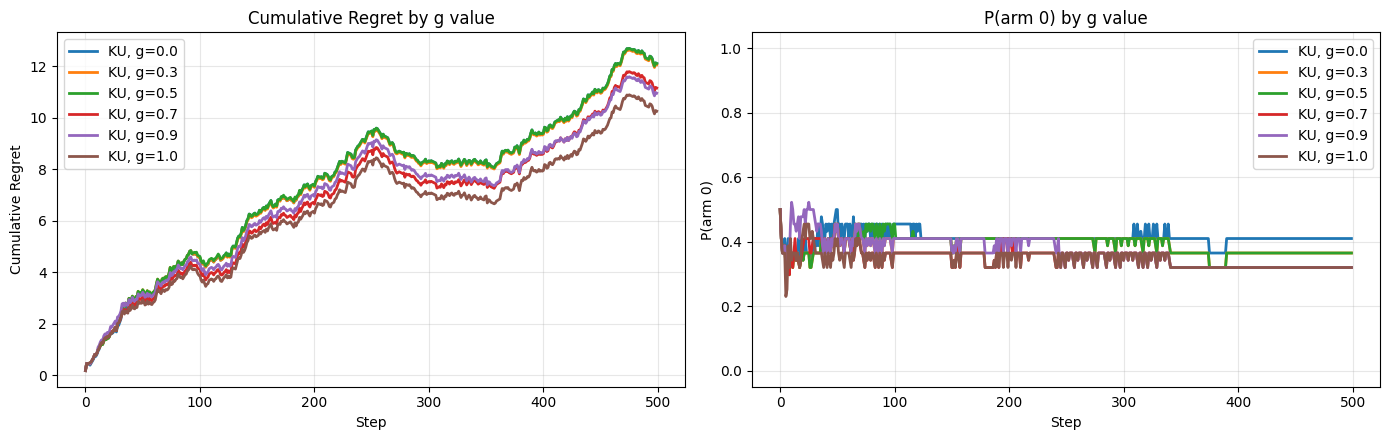

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
for label, res in results_g.items():
    avg = res["average_reward"][0, :]
    regret = np.cumsum(res["optimal_reward"] - avg)
    ax.plot(regret, label=label, linewidth=2)
ax.set_title("Cumulative Regret by g value")
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative Regret")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for label, res in results_g.items():
    p0 = res["probabilities"][:, :, 0].mean(axis=0)
    ax.plot(p0, label=label, linewidth=2)
ax.set_title("P(arm 0) by g value")
ax.set_xlabel("Step")
ax.set_ylabel("P(arm 0)")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()